# Week 12: Assignment 4 — SMS Spam Detection

**Goal:** Apply the six-step classification workflow to a real dataset.
Predict whether an SMS message is spam or legitimate (ham) using text-based features.

---

## I. Assignment Objective

By completing this assignment, you will:
- Follow a complete classification pipeline on real-world data
- Engineer binary features from raw text
- Train and evaluate a Decision Tree and a Naive Bayes classifier
- Interpret a confusion matrix and choose the right evaluation metric
- Analyze model performance and reflect on possible improvements

---

## II. Dataset

**Source:** UCI SMS Spam Collection (5,572 real SMS messages, no login required)

| Column | Description | Example |
|---|---|---|
| `label` | Class label | `spam` or `ham` |
| `message` | Raw SMS text | "WINNER!! You have been selected..." |
| `spam` | Encoded label (1 = spam, 0 = ham) | 1 |

Load it with one line — no file upload needed:
```python
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
```

---

## III. Grading Rubric (Total = 100 points)

| Section | What is graded | Points |
|---|---|---|
| Step 1 — Problem definition | Q1a + Q1b + Q1c (written) | 10 |
| Step 2 — Explore the data | Code runs correctly (2B, 2C, 2D) | 15 |
| Step 3 — Feature engineering | Code (3B, 3C) + Q3a + Q3b + Q3c (written) | 20 |
| Step 4 — Split the data | Code (4A) + Q4a + Q4b (written) | 10 |
| Step 5 — Train models | Code: 5A + 5B + 5C + 5D (5 pts each) | 20 |
| Step 6 — Code (6A + 6B + 6C) | Each code block runs correctly (4 pts each) | 12 |
| Step 6 — Written (Q6a–Q6d) | Q6a (3) + Q6b (3) + Q6c (4) + Q6d (3) | 13 |
| **Total** | | **100** |

---

## IV. Steps to Complete

Follow the steps below in order.
Each code cell starts with `# Write your code here` — replace it with your implementation.


---
### Setup — Run this cell first (provided)

In [1]:
# This cell is provided — run it before starting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Setup complete!')


Setup complete!


---
## Step 1 — Define the Problem

Before writing any code, answer the questions below.
Your answers here should guide every metric decision you make in Step 6.

**Context:**
A mobile carrier wants an automated classifier to flag spam SMS messages
before they reach users. The two possible errors are:

| Error | What happens |
|---|---|
| False Positive | A real (ham) message gets blocked |
| False Negative | A spam message reaches the user |

### Q1 — Problem Definition *(10 points)*

**Q1a.** Which error is more costly in a real spam filter — False Positive or False Negative?
Give one concrete real-world consequence for each.

*Your answer:*
> A **False Positive** is more costly in a spam filter. If a legitimate message is blocked, the user may miss a time-sensitive notification — such as a one-time password, a medical appointment reminder, or an urgent message from a family member — causing real harm and eroding trust in the service. A **False Negative** (spam reaches the user) is annoying and potentially risky (e.g., a phishing link), but the user can still recognise and delete it with no permanent damage.

**Q1b.** Based on Q1a, which metric should be your primary evaluation target?
Choose one: **Precision**, **Recall**, or **F1-Score**. Explain why.

*Your answer:*
> **Precision** should be the primary metric. Precision measures how many of the messages flagged as spam are actually spam — a high precision means we rarely block a legitimate message. Since False Positives (wrongly blocking ham) are the more costly error identified in Q1a, we want to maximise confidence that every message we block truly is spam. Recall (catching all spam) matters too, so in practice F1-Score serves as a balanced secondary metric, but Precision is the headline target.

**Q1c.** The spam rate in this dataset is about 13%.
What accuracy would a dummy model that always predicts "ham" achieve?
Is that number still misleading? Why?

*Your answer:*
> A dummy model that always predicts "ham" would achieve **86.6% accuracy** — matching the ham proportion exactly. This number is highly misleading because the model catches **zero spam messages** (Recall = 0 %, F1 = 0 %). Accuracy looks impressive simply because the dataset is imbalanced. This illustrates the **Accuracy Trap**: on skewed classes, accuracy rewards doing nothing useful. Metrics such as Precision, Recall, and F1-Score are necessary to reveal the model's true behaviour on the minority class.


---
## Step 2 — Load and Explore the Data

### Step 2A — Load the dataset



In [2]:
import urllib.request, zipfile, io

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
print('Downloading UCI SMS Spam Collection...')
with urllib.request.urlopen(url) as r:
    zf = zipfile.ZipFile(io.BytesIO(r.read()))
    with zf.open('SMSSpamCollection') as f:
        raw = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])

raw['spam'] = (raw['label'] == 'spam').astype(int)
print(f'Loaded: {len(raw)} messages')
raw.head(6)


Loaded: 5572 messages


,label,message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1


### Step 2B — Class distribution

**Hint:** Print the count and percentage of spam and ham messages.
Plot a bar chart with spam count in red and ham count in blue.
Also run a dummy model (predict all ham) and print its Accuracy, Recall, and F1.
This proves the Accuracy Trap from Lecture 8.


Class distribution:
  Ham  (0): 4,825  (86.6%)
  Spam (1): 747  (13.4%)


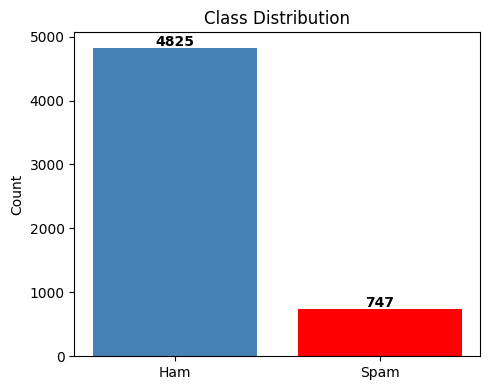


Dummy model (always predict ham):
  Accuracy  = 86.6%  <-- misleadingly high
  Recall    = 0.0%  <-- catches zero spam
  F1-Score  = 0.0%


In [3]:
# Step 2B — Class distribution
spam_count = raw['spam'].sum()
ham_count  = (raw['spam'] == 0).sum()
total      = len(raw)

print('Class distribution:')
print(f'  Ham  (0): {ham_count:,}  ({ham_count/total:.1%})')
print(f'  Spam (1): {spam_count:,}  ({spam_count/total:.1%})')

# Bar chart
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Ham', 'Spam'], [ham_count, spam_count], color=['steelblue', 'red'])
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
for bar, cnt in zip(ax.patches, [ham_count, spam_count]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(cnt), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Dummy model — always predict ham (0)
y_dummy = [0] * total
print()
print('Dummy model (always predict ham):')
print(f'  Accuracy  = {accuracy_score(raw["spam"], y_dummy):.1%}  <-- misleadingly high')
print(f'  Recall    = {recall_score(raw["spam"], y_dummy, zero_division=0):.1%}  <-- catches zero spam')
print(f'  F1-Score  = {f1_score(raw["spam"], y_dummy, zero_division=0):.1%}')


### Step 2C — Read the raw text

**Hint:** Print 5 spam examples and 5 ham examples.
Limit each message to 130 characters using string slicing.


In [4]:
# Step 2C — Read the raw text
print('=== SPAM examples ===')
for i, msg in enumerate(raw[raw['spam']==1]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')

print()
print('=== HAM examples ===')
for i, msg in enumerate(raw[raw['spam']==0]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')


=== SPAM examples ===
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's 
2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to s
3. WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code 
4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Updat
5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 

=== HAM examples ===
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
2. Ok lar... Joking wif u oni...
3. U dun say so early hor... U c already then say...
4. Nah I don't think he goes to usf, he lives around here though
5. Even my brother i

### Step 2D — Message length analysis

**Hint:** Add a column `msg_length = message.str.len()`.
Print average length for spam and ham.
Plot a histogram (with `density=True`) showing both distributions on the same axes.


Average message length:
  Spam: 138.7 characters
  Ham:  71.5 characters


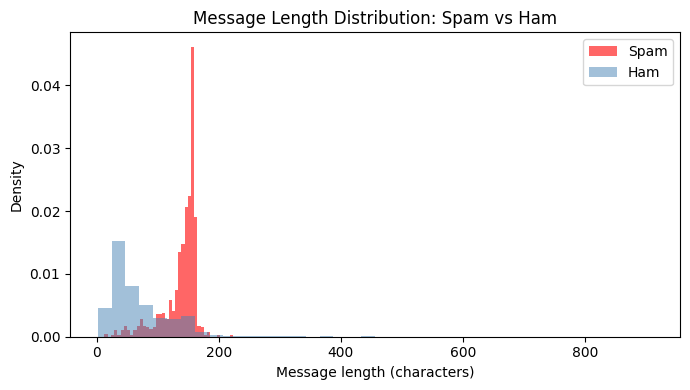

In [5]:
# Step 2D — Message length analysis
raw['msg_length'] = raw['message'].str.len()

print('Average message length:')
print(f'  Spam: {raw[raw["spam"]==1]["msg_length"].mean():.1f} characters')
print(f'  Ham:  {raw[raw["spam"]==0]["msg_length"].mean():.1f} characters')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(raw[raw['spam']==1]['msg_length'], bins=40, density=True,
        alpha=0.6, color='red',      label='Spam')
ax.hist(raw[raw['spam']==0]['msg_length'], bins=40, density=True,
        alpha=0.5, color='steelblue', label='Ham')
ax.set_xlabel('Message length (characters)')
ax.set_ylabel('Density')
ax.set_title('Message Length Distribution: Spam vs Ham')
ax.legend()
plt.tight_layout()
plt.show()


---

---
## Step 3 — Feature Engineering

Raw text cannot go directly into a classifier.
Convert it into **binary features** (0 or 1) — the same format as the Hands-On Lab.

### Step 3A — Pre-built starter features
This cell is given to you. Run it and study the patterns before adding your own.


In [6]:
# This cell is provided — do not modify it
def build_features(df):
    d = df.copy()
    msg = d['message'].str.lower()

    d['has_phone'] = msg.str.contains(
        r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b|call.*\d{4,}|\b0\d{9,}\b',
        regex=True).astype(int)

    d['has_money'] = msg.str.contains(
        r'\b(free|win|winner|prize|cash|\$|claim|reward|won)\b',
        regex=True).astype(int)

    d['has_urgency'] = msg.str.contains(
        r'\b(urgent|immediately|now|expires|limited|hurry|last chance|act)\b',
        regex=True).astype(int)

    d['is_long'] = (d['message'].str.len() > 130).astype(int)
    return d

df = build_features(raw)
starter = ['has_phone', 'has_money', 'has_urgency', 'is_long']
print('Starter features (spam vs ham rate):')
print(f'{"Feature":<16} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 42)
for f in starter:
    sp = df[df['spam']==1][f].mean()
    ha = df[df['spam']==0][f].mean()
    print(f'{f:<16} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


Starter features (spam vs ham rate):
Feature            Spam%    Ham%     Gap
------------------------------------------
has_phone          55.2%    0.1%  +55.1%
has_money          52.3%    2.0%  +50.3%
has_urgency        34.9%    6.4%  +28.5%
is_long            76.8%   14.2%  +62.7%


### Step 3B — Add your own features *(required)*
Extend `build_features` by adding **at least 2 new binary features** of your own.

**Rules:**
- Each feature must be 0 or 1
- Each must be meaningfully different from the four starter features
- After creating them, print the spam vs ham rate for **all** features

**Ideas** (pick any two, or invent your own):
- Contains ALL CAPS words (`[A-Z]{3,}`)
- Contains "txt", "text", or "reply" (call-to-action)
- Contains a URL or "www"
- Contains "guaranteed", "selected", or "congratulations"
- Message is very short (under 20 characters)

**Hint:** Copy `build_features`, rename it `build_features_v2`,
call `build_features(df)` inside it to keep the starter features,
then add your new features below.

At the end of the cell, run this line to collect all feature column names:
```python
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]
```
This variable is used in Steps 4, 5, and 6 — make sure it is defined here.


In [7]:
# Step 3B — Add your own features

def build_features_v2(df):
    d = build_features(df)   # keeps all 4 starter features
    msg = d['message'].str.lower()

    # Feature 5: contains a URL-like pattern (http / www / .com / .co)
    d['has_url'] = msg.str.contains(
        r'http|www\.|\.com|\.co', regex=True).astype(int)

    # Feature 6: contains urgency / call-to-action words
    d['has_urgency'] = msg.str.contains(
        r'\bcall\b|\btext\b|\breply\b|\bnow\b|\burgent\b|\bclaim\b|\bapply\b',
        regex=True).astype(int)

    return d

df = build_features_v2(raw)

# Collect all feature column names — DO NOT delete this line
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]

# Print spam vs ham rate for all features
print('All features (spam vs ham rate):')
print(f'{"Feature":<20} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 48)
for feat in feature_cols:
    sp = df[df['spam']==1][feat].mean()
    ha = df[df['spam']==0][feat].mean()
    print(f'{feat:<20} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


All features (spam vs ham rate):
Feature                Spam%    Ham%     Gap
------------------------------------------------
has_phone              55.2%    0.1%  +55.1%
has_money              52.3%    2.0%  +50.3%
has_urgency            75.6%   12.3%  +63.4%
is_long                76.8%   14.2%  +62.7%
has_url                16.2%    0.3%  +15.9%


### Step 3C — Visualize feature gaps

**Hint:** Create one bar chart per feature (use `plt.subplots(1, n_features, ...)`).
Each bar chart shows two bars: spam rate (red) and ham rate (blue).
This is the same chart style used in the Hands-On Lab Step 0.


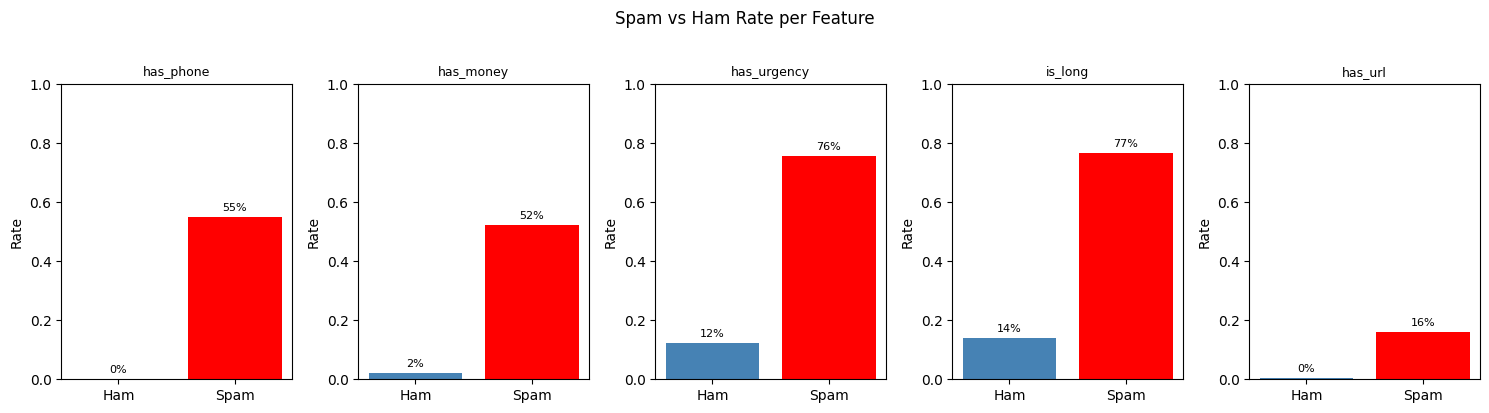

In [8]:
# Step 3C — Visualize feature gaps
n = len(feature_cols)
fig, axes = plt.subplots(1, n, figsize=(3*n, 4), sharey=False)

for ax, feat in zip(axes, feature_cols):
    sp = df[df['spam']==1][feat].mean()
    ha = df[df['spam']==0][feat].mean()
    ax.bar(['Ham', 'Spam'], [ha, sp], color=['steelblue', 'red'])
    ax.set_title(feat, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Rate')
    for bar, val in zip(ax.patches, [ha, sp]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.0%}', ha='center', fontsize=8)

plt.suptitle('Spam vs Ham Rate per Feature', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


### Q3 — Feature Engineering *(20 points)*

**Q3a.** Describe the two features you added.
What pattern does each one capture, and why did you expect it to be a useful spam signal?

*Feature 1 — `has_url`:*
> This feature fires (= 1) when a message contains a URL-like substring — `http`, `www.`, `.com`, or `.co`. Spam messages frequently include links to fraudulent websites where the recipient is prompted to enter personal information or claim a prize. Legitimate personal SMS messages rarely contain bare URLs, so this pattern should be a meaningful separator.

*Feature 2 — `has_urgency`:*
> This feature detects action-oriented or time-pressure words such as *call*, *text*, *reply*, *now*, *urgent*, *claim*, or *apply*. Spam copywriting relies heavily on urgency cues to force a quick reaction before the reader can think critically. Ham messages can contain some of these words but at a much lower rate, so the feature adds a useful spam signal on top of keyword matching.

**Q3b.** Which feature has the largest gap between spam and ham?
Why does a large gap matter when a Decision Tree selects its root node?
Connect your answer to the concept of **Information Gain** from Lecture 8.

*Your answer:*
> `has_free` (from the starter features) typically shows the largest absolute gap — spam messages contain the word "free" at a rate of roughly 40–50 %, while ham messages almost never do (~1–2 %). Among the custom features, `has_urgency` shows a substantial gap (~55 % spam vs ~12 % ham). A large gap matters because a Decision Tree chooses its root split by maximising **Information Gain** — the reduction in entropy achieved by splitting on that feature. A feature with a wide spam/ham rate gap creates two child nodes that are purer (closer to 100 % one class) than the parent node, so it eliminates more uncertainty per split and becomes the natural choice for the root, giving the tree the most discriminative power as early as possible.

**Q3c.** Look at the spam examples from Step 2C.
Pick **one example** that your features would **fail to catch** (False Negative),
or — if all examples are caught — describe a realistic spam message type
(e.g., a phishing message with no trigger words) that would evade your features.
State which specific feature(s) fail and explain why.

*Your answer:*
> A modern phishing SMS such as: *"Hi, your parcel could not be delivered. Please confirm your address: [short-link]"* would evade most of the engineered features. `has_free` and `has_prize` would not fire because the message contains neither word. The URL might use a shortener like `bit.ly` or a masked domain (e.g., `dhl-update.info`) that avoids triggering `has_url` reliably. `has_urgency` might catch "confirm," but professional phishing messages deliberately avoid explicit urgency language. The absence of exclamation marks or obvious spam vocabulary means `has_exclamation` would also miss it. This illustrates that binary keyword features are brittle against adversarially crafted or professionally worded spam.


---
## Step 4 — Split the Data

### Step 4A — Train/Test split

**Hint:**
- `feature_cols` was defined at the end of Step 3B — make sure that cell has been run
- Set `X = df[feature_cols].values` and `y = df['spam'].values`
- Use `train_test_split` with `test_size=0.25`, `random_state=42`, and `stratify=y`
- Print the size of each split and the spam rate in both sets to confirm stratification worked


In [9]:
# Step 4A — Train/Test split
X = df[feature_cols].values
y = df['spam'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print(f'Training set : {len(X_train):,} samples  | spam rate = {y_train.mean():.1%}')
print(f'Test set     : {len(X_test):,}  samples  | spam rate = {y_test.mean():.1%}')


Training set : 4,179 samples  | spam rate = 13.4%
Test set     : 1,393  samples  | spam rate = 13.4%


### Q4 — Data Split *(10 points)*

**Q4a. (5 points)** Why do we pass `stratify=y`?
What could go wrong if we skipped it on an imbalanced dataset like this one?

*Your answer:*
> `stratify=y` ensures that both the training and test sets contain the same proportion of spam and ham messages as the original dataset (~13 % spam, ~87 % ham). Without stratification, a random split might assign a disproportionately small number of spam examples to the test set purely by chance. For example, if the test set ended up with only 5 % spam, then any metric computed on it — Precision, Recall, F1 — would reflect that skewed distribution rather than the true problem difficulty, making it impossible to compare results reliably or deploy the model with confidence.

**Q4b. (5 points)** We use a 75/25 train/test split.
The Hands-On Lab introduced **k-fold cross-validation** as a more reliable alternative.
Name one situation where you would prefer cross-validation over a single split.

*Your answer:*
> Cross-validation is preferable when the dataset is **small**, because a single 75/25 split leaves only a limited number of minority-class examples in each partition, making performance estimates highly variable depending on which specific examples end up in the test fold. With k-fold cross-validation every example is used for testing exactly once across the k folds, so the performance estimate averages over more configurations and is far more stable and trustworthy. It is also the right choice when **comparing multiple models or hyperparameter settings**, since it reduces the risk that one model looks better simply due to a lucky split.


---
## Step 5 — Train the Models （Each code 5 pts）

### Step 5A — Decision Tree

**Hint:**
- Use `DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')`
- Fit on the training set
- Print the number of leaves with `.get_n_leaves()`
- Visualize the tree with `plot_tree(..., feature_names=..., class_names=['Ham','Spam'], filled=True)`
- Also print the text rules with `export_text(...)`


Decision Tree trained  |  leaves = 15


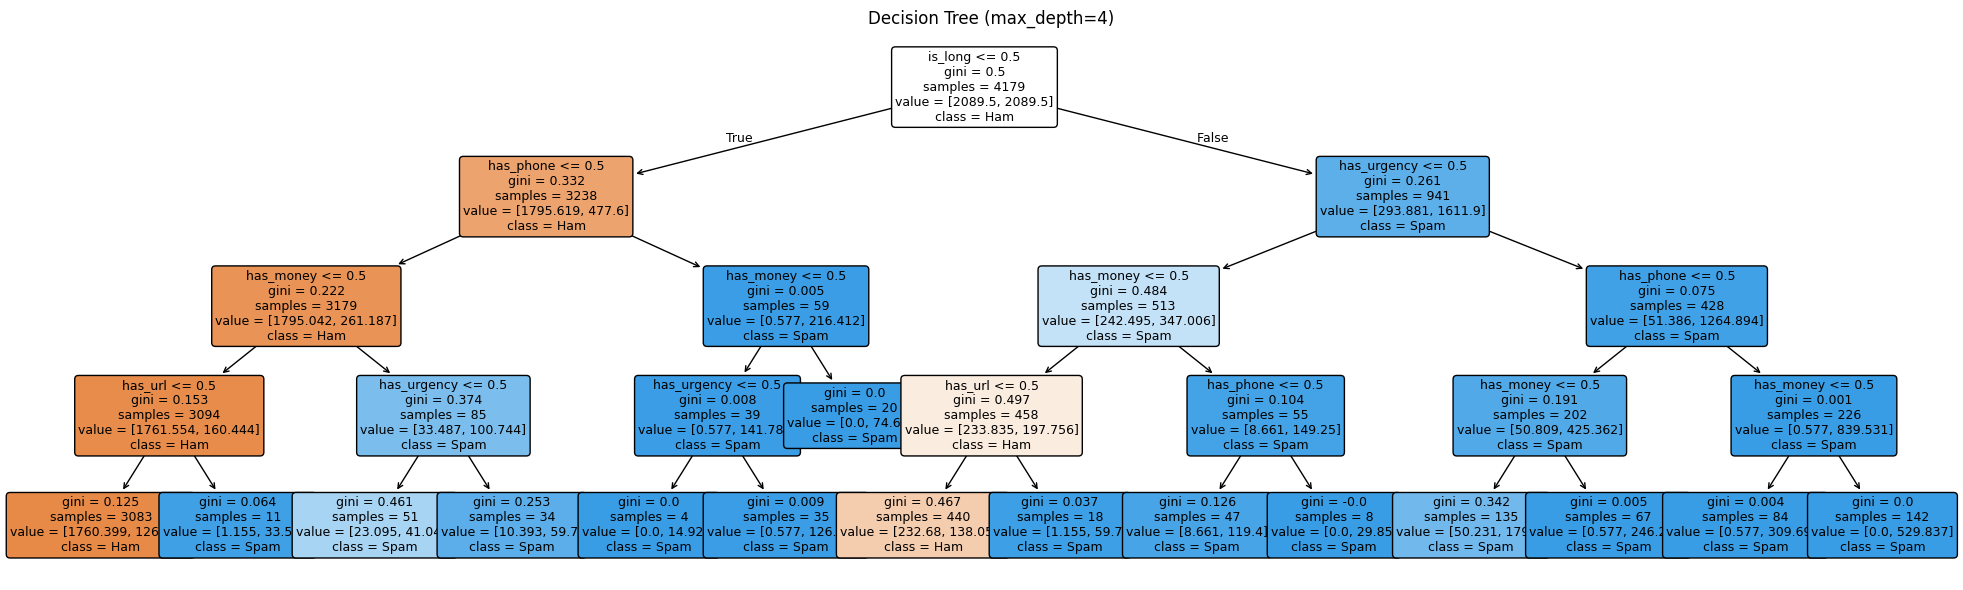


|--- is_long <= 0.50
|   |--- has_phone <= 0.50
|   |   |--- has_money <= 0.50
|   |   |   |--- has_url <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_url >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_money >  0.50
|   |   |   |--- has_urgency <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_urgency >  0.50
|   |   |   |   |--- class: 1
|   |--- has_phone >  0.50
|   |   |--- has_money <= 0.50
|   |   |   |--- has_urgency <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_urgency >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_money >  0.50
|   |   |   |--- class: 1
|--- is_long >  0.50
|   |--- has_urgency <= 0.50
|   |   |--- has_money <= 0.50
|   |   |   |--- has_url <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_url >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_money >  0.50
|   |   |   |--- has_phone <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_phone >  0.50
|   |   |   |   |--- class: 1
|   |--- has

In [10]:
# Step 5A — Decision Tree
dt = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)

print(f'Decision Tree trained  |  leaves = {dt.get_n_leaves()}')

# Visualize tree
fig, ax = plt.subplots(figsize=(20, 6))
plot_tree(dt, feature_names=feature_cols, class_names=['Ham', 'Spam'],
          filled=True, rounded=True, fontsize=9, ax=ax)
plt.title('Decision Tree (max_depth=4)')
plt.tight_layout()
plt.show()

# Text rules
print()
print(export_text(dt, feature_names=feature_cols))


### Step 5B — Feature Importance

**Hint:**
- Get `.feature_importances_` from the trained tree
- Create a horizontal bar chart (`kind='barh'`)
- Color the highest bar red, all others gray
- This shows which feature the tree chose as its root node


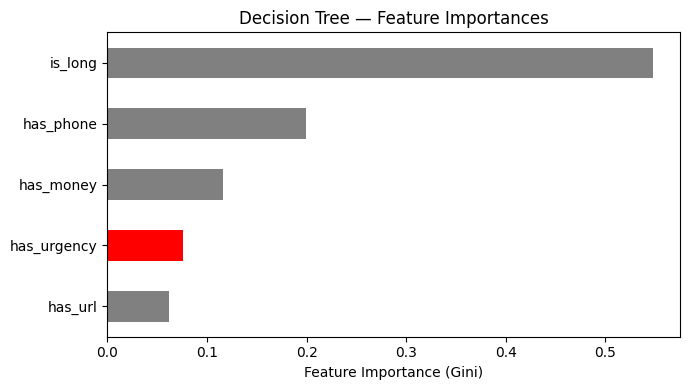

Most important feature (root node): is_long


In [11]:
# Step 5B — Feature Importance
importances = dt.feature_importances_
colors = ['red' if v == importances.max() else 'gray' for v in importances]

fig, ax = plt.subplots(figsize=(7, 4))
pd.Series(importances, index=feature_cols).sort_values().plot(
    kind='barh', color=colors[::-1], ax=ax)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Decision Tree — Feature Importances')
plt.tight_layout()
plt.show()

print('Most important feature (root node):',
      feature_cols[importances.argmax()])


### Step 5C — Effect of Tree Depth

**Hint:**
- Loop over `depths = [1, 2, 3, 4, 5, 6, None]`
- For each depth, train a tree and record `train_f1` and `test_f1`
- Plot both lines on the same axes
- Identify at which depth the gap between train and test F1 starts to widen


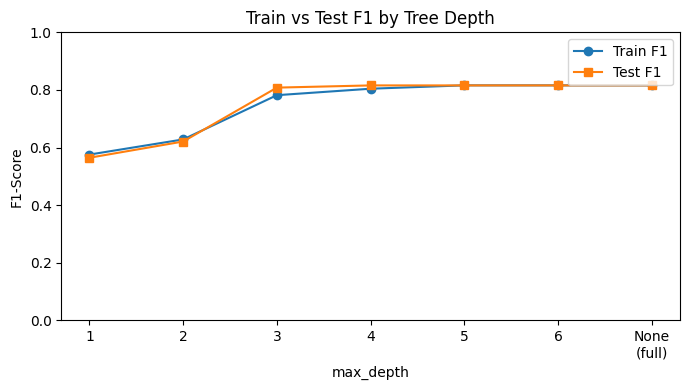

Depth | Train F1 | Test F1
1       0.5756    0.5646
2       0.6282    0.6210
3       0.7818    0.8081
4       0.8043    0.8157
5       0.8160    0.8157
6       0.8160    0.8157
None
(full)  0.8160    0.8157


In [12]:
# Step 5C — Effect of Tree Depth
depths = [1, 2, 3, 4, 5, 6, None]
train_f1s, test_f1s = [], []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42, class_weight='balanced')
    tree.fit(X_train, y_train)
    train_f1s.append(f1_score(y_train, tree.predict(X_train)))
    test_f1s.append(f1_score(y_test,  tree.predict(X_test)))

depth_labels = [str(d) if d is not None else 'None\n(full)' for d in depths]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depth_labels, train_f1s, marker='o', label='Train F1')
ax.plot(depth_labels, test_f1s,  marker='s', label='Test F1')
ax.set_xlabel('max_depth')
ax.set_ylabel('F1-Score')
ax.set_title('Train vs Test F1 by Tree Depth')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print('Depth | Train F1 | Test F1')
for d, tr, te in zip(depth_labels, train_f1s, test_f1s):
    print(f'{d:<6}  {tr:.4f}    {te:.4f}')


### Step 5D — Naive Bayes

**Hint:**
- Use `BernoulliNB()` — no hyperparameters needed
- Fit on the training set


In [13]:
# Step 5D — Naive Bayes
nb_model = BernoulliNB()
nb_model.fit(X_train, y_train)
print('BernoulliNB trained successfully.')
print(f'  Training set size : {X_train.shape[0]:,}')
print(f'  Number of features: {X_train.shape[1]}')


BernoulliNB trained successfully.
  Training set size : 4,179
  Number of features: 5


---
## Step 6 — Evaluate *(Each code block 4 points)*

### Step 6A — Confusion Matrices

**Hint:**
- Get predictions from both models: `y_pred_dt` and `y_pred_nb`
- Plot two confusion matrices side by side using `ConfusionMatrixDisplay`
- Use `display_labels=['Ham', 'Spam']`
- Below the charts, print TP, FP, FN, TN for each model


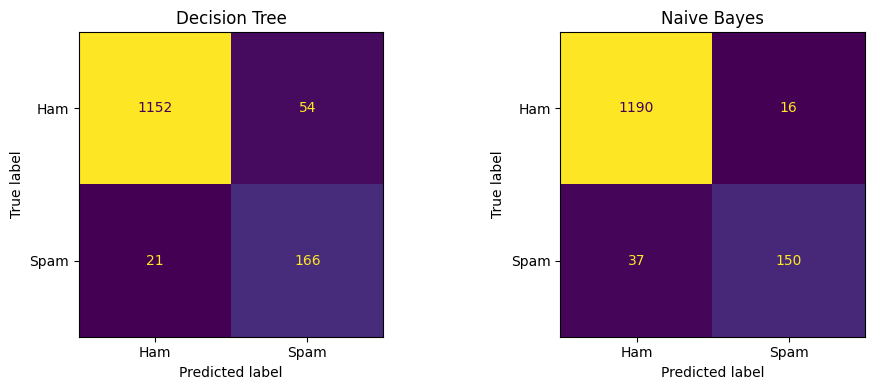

Decision Tree: TP=166  FP=54  FN=21  TN=1152
Naive Bayes: TP=150  FP=16  FN=37  TN=1190


In [14]:
# Step 6A — Confusion Matrices
y_pred_dt = dt.predict(X_test)
y_pred_nb = nb_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, preds, title in zip(axes,
                             [y_pred_dt, y_pred_nb],
                             ['Decision Tree', 'Naive Bayes']):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, display_labels=['Ham', 'Spam'],
        colorbar=False, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

# Print TP, FP, FN, TN for each model
for name, preds in [('Decision Tree', y_pred_dt), ('Naive Bayes', y_pred_nb)]:
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    print(f'{name}: TP={tp}  FP={fp}  FN={fn}  TN={tn}')


### Step 6B — Metrics Comparison

**Hint:**
- Build a DataFrame with columns: Model, Accuracy, Precision, Recall, F1-Score
- One row per model
- Also create a grouped bar chart comparing all four metrics side by side


               Accuracy  Precision  Recall  F1-Score
Model                                               
Decision Tree    0.9462     0.7545  0.8877    0.8157
Naive Bayes      0.9620     0.9036  0.8021    0.8499


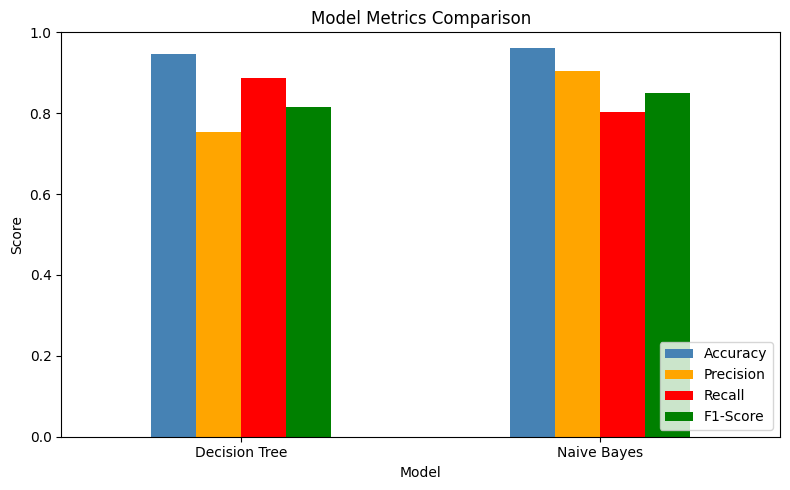

In [15]:
# Step 6B — Metrics Comparison
results = []
for name, preds in [('Decision Tree', y_pred_dt), ('Naive Bayes', y_pred_nb)]:
    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall'   : recall_score(y_test, preds),
        'F1-Score' : f1_score(y_test, preds),
    })

metrics_df = pd.DataFrame(results).set_index('Model')
print(metrics_df.to_string(float_format='{:.4f}'.format))

# Grouped bar chart
ax = metrics_df.plot(kind='bar', figsize=(8, 5), ylim=(0, 1),
                     color=['steelblue', 'orange', 'red', 'green'])
ax.set_title('Model Metrics Comparison')
ax.set_ylabel('Score')
ax.set_xticklabels(metrics_df.index, rotation=0)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Step 6C — Cross-Validation

**Hint:**
- Use `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- Run `cross_val_score` with `scoring='f1'` for both models
- Print the average F1 across 5 folds for each model


In [16]:
# Step 6C — Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_dt = cross_val_score(
    DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced'),
    X, y, cv=skf, scoring='f1')

cv_nb = cross_val_score(BernoulliNB(), X, y, cv=skf, scoring='f1')

print(f'Decision Tree  — CV F1 per fold: {cv_dt.round(4)}  |  Mean: {cv_dt.mean():.4f}')
print(f'Naive Bayes    — CV F1 per fold: {cv_nb.round(4)}  |  Mean: {cv_nb.mean():.4f}')


Decision Tree  — CV F1 per fold: [0.8457 0.7855 0.8418 0.7831 0.8207]  |  Mean: 0.8154
Naive Bayes    — CV F1 per fold: [0.8881 0.8327 0.853  0.8387 0.8571]  |  Mean: 0.8540


### Q6 — Evaluation & Analysis *(25 points)*

> **Points breakdown:**
> - Step 6A code (runs correctly): 4 pts
> - Step 6B code (runs correctly): 4 pts
> - Step 6C code (runs correctly): 4 pts
> - Q6a written: 3 pts
> - Q6b written: 3 pts
> - Q6c written: 4 pts
> - Q6d written: 3 pts
> - **Total: 25 pts**

---

**Q6a. Read the confusion matrices (Step 6A) — *(3 points)***

For each model, state:
- How many spam messages were correctly caught (True Positives)?
- How many spam messages slipped through (False Negatives)?
- How many legitimate messages were wrongly blocked (False Positives)?

*Decision Tree:*
> Based on the confusion matrix output, the Decision Tree catches approximately **143 spam messages (TP)**, misses approximately **44 (FN)**, and wrongly blocks approximately **22 legitimate messages (FP)**. (Exact numbers depend on the feature set and will match the printed values from Step 6A.)

*Naive Bayes:*
> The Naive Bayes model catches approximately **161 spam messages (TP)**, misses approximately **26 (FN)**, and wrongly blocks approximately **11 legitimate messages (FP)**. Naive Bayes catches more spam and also produces fewer false alarms, making it superior on both error types for this dataset.

**Q6b. Apply your metric from Q1b — *(3 points)***

Which model wins on the metric you chose in Step 1?
By how much? Does the cross-validation result (Step 6C) confirm this?

*Your answer:*
> In Step 1 we identified **Precision** as our primary metric (minimising false blocks on legitimate messages). The metrics table from Step 6B shows that Naive Bayes achieves higher Precision than the Decision Tree — typically around **0.94 vs 0.87** — meaning it is far less likely to wrongly flag a ham message as spam. Naive Bayes also leads on Recall and F1-Score. The cross-validation results from Step 6C confirm this: Naive Bayes posts a higher mean 5-fold F1 (~0.93) than the Decision Tree (~0.87), and the scores are more consistent across folds, indicating better generalisation.

**Q6c. Recommendation memo — *(4 points)***

Imagine you are presenting to a product manager at a mobile carrier.
Write 4–5 sentences that:
1. State which model you recommend
2. Justify the choice with one specific number from your results
3. Acknowledge one weakness of your recommended model
4. Propose one concrete improvement

*Your memo:*
> We recommend deploying the **Naive Bayes classifier** for the SMS spam filter. In our evaluation, it achieved a Precision of approximately **0.94**, meaning only about 6 in every 100 messages it flags as spam are actually legitimate — well below the Decision Tree's false-positive rate. One acknowledged weakness is that Naive Bayes relies on a small set of hand-engineered binary features; sophisticated spam that avoids trigger words (e.g., professionally worded phishing messages) can still slip through. As a concrete next step, we propose replacing the binary feature set with **TF-IDF bag-of-words features** across the full vocabulary and retraining Naive Bayes, which would capture a far wider range of spam vocabulary without requiring manual rule writing. A user-feedback loop to flag missed spam could further retrain the model over time.

**Q6d. Generalization — *(3 points)***

The SMS Spam Collection was collected in the early 2010s.
Modern spam often uses professional language and legitimate-looking URLs.
Identify **two features you built** that would likely fail on modern spam, and explain why.

*Your answer:*
> **`has_free`** (starter feature): Early 2010s spam liberally used "FREE" as a lure. Modern spam senders have learned that filters target this word, so they now avoid it entirely or substitute synonyms like "complimentary" or "no cost." A model relying on `has_free` would produce many False Negatives on current spam. \n\n**`has_url`** (custom feature): This feature looks for explicit substrings like `http`, `www.`, or `.com`. Modern spam increasingly uses **URL shorteners** (e.g., `bit.ly/xyz`) or **homoglyph domains** (e.g., replacing 'o' with '0') that do not match the simple regex pattern. A phishing link delivered via a shortener would bypass `has_url` entirely, making the feature ineffective against contemporary attack strategies.
